## **모델 훈련 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch04 연습문제 1, 5, 9, 10
- 개념 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

### **1. 수백만 개의 특성을 가진 훈련 세트에서는 어떤 선형 회귀 알고리즘을 사용할 수 있을까요?**
___


: 확률적 경사 하강법이나 미니배치 경사 하강법을 사용할 수 있음. 훈련 세트가 메모리 크기에 맞으면 배치 경사 하강법도 가능함

### **2. 배치 경사 하강법을 사용하고 에포크마다 검증 오차를 그래프로 나타내봤습니다. 검증 오차가 일정하게 상승되고 있다면 어떤 일이 일어나고 있는 걸까요? 이 문제를 어떻게 해결할 수 있나요?**
___

: 검증 오차가 일정하게 상승되고 있다면, 학습률이 너무 높아 알고리즘이 발산한다는 의미이기 때문에 학습률을 낮춰 다시 훈련시켜야 함

### **3. 릿지 회귀를 사용했을 때 훈련 오차가 검증 오차가 거의 비슷하고 둘 다 높았습니다. 이 모델에는 높은 편향이 문제인가요, 아니면 높은 분산이 문제인가요? 규제 하이퍼파라미터 $\alpha$를 증가시켜야 할까요 아니면 줄여야 할까요?**
___

: 훈련 오차와 검증 오차가 모두 높은 경우 과소적합을 의심할 수 있으며, 이는 높은 편향이 문제인 경우로, 규제 하이퍼 파라미터를 줄여야 함

### **4. 다음과 같이 사용해야 하는 이유는?**
___
- 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀
- 릿지 회귀 대신 라쏘 회귀
- 라쏘 회귀 대신 엘라스틱넷

1. 평범한 선형 회귀 대신 릿지 회귀는 큰 계수에 패널티를 주어 모델의 복잡도와 과적합을 줄이고 일반화 성능을 줄임

2. 릿지 회귀 대신 라쏘 회귀는 중요하지 않은 변수의 계수를 0으로 만들어 변수 선택 효과가 있음

3. 라쏘 회귀 대신 엘라스틱넷은 L1, L2 규제를 함께 활용하여 라쏘의 변수 선택효과와 릿지의 안정성을 동시에 얻을 수 있음

### **추가) 조기 종료를 사용한 배치 경사 하강법으로 iris 데이터를 활용해 소프트맥스 회귀를 구현해보세요(사이킷런은 사용하지 마세요)**


---



X shape: (150, 4)
y shape: (150,)
X[:5]:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
y[:5]:
[0 0 0 0 0]

Train: (90, 4)
Validation: (30, 4)
Test: (30, 4)
Epoch   50 | Train Loss: 0.2757 | Val Loss: 0.3188 | Train Acc: 0.9111 | Val Acc: 0.9000
Epoch  100 | Train Loss: 0.2120 | Val Loss: 0.2646 | Train Acc: 0.9444 | Val Acc: 0.9333
Epoch  150 | Train Loss: 0.1764 | Val Loss: 0.2329 | Train Acc: 0.9667 | Val Acc: 0.9333
Epoch  200 | Train Loss: 0.1535 | Val Loss: 0.2121 | Train Acc: 0.9667 | Val Acc: 0.9333
Epoch  250 | Train Loss: 0.1377 | Val Loss: 0.1971 | Train Acc: 0.9667 | Val Acc: 0.9333
Epoch  300 | Train Loss: 0.1261 | Val Loss: 0.1856 | Train Acc: 0.9667 | Val Acc: 0.9333
Epoch  350 | Train Loss: 0.1172 | Val Loss: 0.1767 | Train Acc: 0.9667 | Val Acc: 0.9333
Epoch  400 | Train Loss: 0.1102 | Val Loss: 0.1696 | Train Acc: 0.9667 | Val Acc: 0.9333
Epoch  450 | Train Loss: 0.1045 | Val Loss: 0.1635 | Train Acc: 0.9667 | Val Acc: 

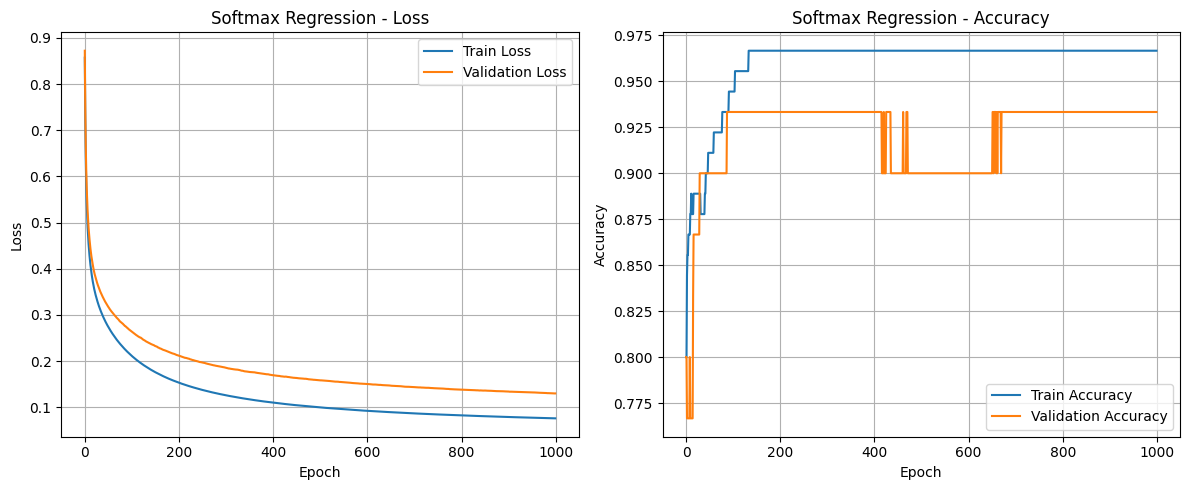

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

iris = load_iris()

X = iris["data"]
y = iris["target"]


# 1. 데이터 확인
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X[:5]:")
print(X[:5])

print("y[:5]:")
print(y[:5])


# 2. 데이터 섞기
np.random.seed(42)

indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]


# 3. Train / Validation / Test 분리
train_size = 90
val_size = 30

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]


print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# 4. 데이터 표준화
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std


# 5. One-Hot Encoding
num_classes = 3

Y_train = np.zeros((len(y_train), num_classes))
Y_train[np.arange(len(y_train)), y_train] = 1

Y_val = np.zeros((len(y_val), num_classes))
Y_val[np.arange(len(y_val)), y_val] = 1

Y_test = np.zeros((len(y_test), num_classes))
Y_test[np.arange(len(y_test)), y_test] = 1


# 6. Softmax 함수
def softmax(z):

    # overflow 방지
    z = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z)

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# 7. Cross Entropy Loss
def cross_entropy(y_true, y_pred):

    # log(0) 방지
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

    loss = -np.mean(
        np.sum(y_true * np.log(y_pred), axis=1)
    )

    return loss


# 8. 정확도
def accuracy(y_true, y_pred):

    predicted = np.argmax(y_pred, axis=1)
    actual = np.argmax(y_true, axis=1)

    return np.mean(predicted == actual)


# 9. 가중치 초기화
n_features = X_train.shape[1]

W = np.zeros((n_features, num_classes))
b = np.zeros((1, num_classes))


# 10. 학습 설정
learning_rate = 0.05
batch_size = 16

max_epochs = 1000
patience = 30
min_delta = 0.00001

best_val_loss = np.inf

best_W = W.copy()
best_b = b.copy()

patience_count = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []


# 11. 배치 경사 하강법
for epoch in range(max_epochs):

    indices = np.random.permutation(len(X_train))

    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]


    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]


        z = X_batch @ W + b
        y_pred = softmax(z)

        error = y_pred - Y_batch
        dW = (X_batch.T @ error) / len(X_batch)
        db = np.mean(error, axis=0, keepdims=True)

        W = W - learning_rate * dW
        b = b - learning_rate * db

    train_pred = softmax(X_train @ W + b)
    val_pred = softmax(X_val @ W + b)

    train_loss = cross_entropy(Y_train, train_pred)
    val_loss = cross_entropy(Y_val, val_pred)
    train_acc = accuracy(Y_train, train_pred)
    val_acc = accuracy(Y_val, val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)


    # Early Stopping

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_W = W.copy()
        best_b = b.copy()
        patience_count = 0

    else:
        patience_count += 1

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch + 1:4d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


    # Early Stopping
    if patience_count >= patience:

        print("\nEarly Stopping!")
        print("학습 종료 Epoch:", epoch + 1)

        break


# 12. 가장 좋은 모델 복원
W = best_W
b = best_b


# 13. 테스트 데이터 평가
test_pred = softmax(X_test @ W + b)
test_loss = cross_entropy(Y_test, test_pred)
test_acc = accuracy(Y_test, test_pred)


print("Test Loss     :", test_loss)
print("Test Accuracy :", test_acc)


# 14. 실제값 vs 예측값
predicted_classes = np.argmax(test_pred, axis=1)

print("\n실제값 / 예측값")

for actual, predicted in zip(y_test, predicted_classes):

    print(
        f"실제: {actual}  "
        f"예측: {predicted}"
    )


# 15. Loss 그래프
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Softmax Regression - Loss")
plt.legend()
plt.grid()


# 16. Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Softmax Regression - Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
